# 01: Data Overview

**Dataset:** Google Analytics Sample Ecommerce Dataset (BigQuery public data)  
**Goal:** Understand schema, explore nested fields, and check data quality before EDA.  
**Reference:** [GA BigQuery Export Schema](https://support.google.com/analytics/answer/3437719?hl=en)

In [1]:
import os
from google.cloud import bigquery
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 1000)

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../credentials/bq-key.json"
client = bigquery.Client()
print("BigQuery client ready.")

BigQuery client ready.


## 1. Dataset Overview

In [2]:
# INFORMATION_SCHEMA and __TABLES__ are blocked on public datasets, use client API instead
# Note: Google-ecommerce-dataset-table is an empty placeholder, ignored
dataset_ref = client.dataset('google_analytics_sample', project='bigquery-public-data')
tables = list(client.list_tables(dataset_ref))
print(f"Total tables: {len(tables)}")
for t in tables:
    print(t.table_id)

Total tables: 369
Google-ecommerce-dataset-table
daily_total_visits
daily_visits
ga_sessions_20160801
ga_sessions_20160802
ga_sessions_20160803
ga_sessions_20160804
ga_sessions_20160805
ga_sessions_20160806
ga_sessions_20160807
ga_sessions_20160808
ga_sessions_20160809
ga_sessions_20160810
ga_sessions_20160811
ga_sessions_20160812
ga_sessions_20160813
ga_sessions_20160814
ga_sessions_20160815
ga_sessions_20160816
ga_sessions_20160817
ga_sessions_20160818
ga_sessions_20160819
ga_sessions_20160820
ga_sessions_20160821
ga_sessions_20160822
ga_sessions_20160823
ga_sessions_20160824
ga_sessions_20160825
ga_sessions_20160826
ga_sessions_20160827
ga_sessions_20160828
ga_sessions_20160829
ga_sessions_20160830
ga_sessions_20160831
ga_sessions_20160901
ga_sessions_20160902
ga_sessions_20160903
ga_sessions_20160904
ga_sessions_20160905
ga_sessions_20160906
ga_sessions_20160907
ga_sessions_20160908
ga_sessions_20160909
ga_sessions_20160910
ga_sessions_20160911
ga_sessions_20160912
ga_sessions_2016

In [3]:
# daily_total_visits: matches ga_sessions row count (1711 on 2016-08-01), total sessions per day
# daily_visits: definition unclear, does not match total sessions or unique visitors, treat as unknown
df_daily_total = client.query("""
    SELECT * FROM `bigquery-public-data.google_analytics_sample.daily_total_visits` LIMIT 5
""").to_dataframe()

df_daily_visits = client.query("""
    SELECT * FROM `bigquery-public-data.google_analytics_sample.daily_visits` LIMIT 5
""").to_dataframe()

print("daily_total_visits:"); display(df_daily_total)
print("\ndaily_visits:");      display(df_daily_visits)

daily_total_visits:


,visit_date,total_visits
0,2016-08-01,1711
1,2016-08-02,2140
2,2016-08-03,2890
3,2016-08-04,3161
4,2016-08-05,2702



daily_visits:


,visit_date,total_visits
0,2016-08-01,1296
1,2016-08-02,1963
2,2016-08-03,2703
3,2016-08-04,3176
4,2016-08-05,2994


In [4]:
# _TABLE_SUFFIX: pseudo-column = everything after 'ga_sessions_' in the table name
# Use BETWEEN to filter date range and reduce bytes scanned
query = """
SELECT
    MIN(_TABLE_SUFFIX) AS earliest_date,
    MAX(_TABLE_SUFFIX) AS latest_date,
    COUNT(DISTINCT _TABLE_SUFFIX) AS num_days
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
"""
df_range = client.query(query).to_dataframe()
df_range

,earliest_date,latest_date,num_days
0,20160801,20170801,366


## 2. Schema Exploration

In [5]:
df_sessions = client.query("""
    SELECT * FROM `bigquery-public-data.google_analytics_sample.ga_sessions_20160801`
    LIMIT 20
""").to_dataframe()

print("Shape:", df_sessions.shape)
print("Columns:", df_sessions.columns.tolist())
df_sessions.head()

Shape: (20, 15)
Columns: ['visitorId', 'visitNumber', 'visitId', 'visitStartTime', 'date', 'totals', 'trafficSource', 'device', 'geoNetwork', 'customDimensions', 'hits', 'fullVisitorId', 'userId', 'channelGrouping', 'socialEngagementType']


,visitorId,visitNumber,visitId,visitStartTime,date,totals,trafficSource,device,geoNetwork,customDimensions,hits,fullVisitorId,userId,channelGrouping,socialEngagementType
0,<NA>,1,1470046245,1470046245,20160801,"{'visits': 1, 'hits': 24, 'pageviews': 17, 'ti...","{'referralPath': None, 'campaign': '(not set)'...","{'browser': 'Firefox', 'browserVersion': 'not ...","{'continent': 'Europe', 'subContinent': 'Weste...","[{'index': 4, 'value': 'EMEA'}]","[{'hitNumber': 1, 'time': 0, 'hour': 3, 'minut...",895954260133011192,NaN,Organic Search,Not Socially Engaged
1,<NA>,1,1470084717,1470084717,20160801,"{'visits': 1, 'hits': 24, 'pageviews': 18, 'ti...","{'referralPath': None, 'campaign': '(not set)'...","{'browser': 'Internet Explorer', 'browserVersi...","{'continent': 'Americas', 'subContinent': 'Nor...","[{'index': 4, 'value': 'North America'}]","[{'hitNumber': 1, 'time': 0, 'hour': 13, 'minu...",0288478011259077136,NaN,Direct,Not Socially Engaged
2,<NA>,3,1470078988,1470078988,20160801,"{'visits': 1, 'hits': 27, 'pageviews': 17, 'ti...","{'referralPath': None, 'campaign': '(not set)'...","{'browser': 'Safari', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Nor...","[{'index': 4, 'value': 'North America'}]","[{'hitNumber': 1, 'time': 0, 'hour': 12, 'minu...",6440789996634275026,NaN,Organic Search,Not Socially Engaged
3,<NA>,4,1470075581,1470075581,20160801,"{'visits': 1, 'hits': 27, 'pageviews': 19, 'ti...","{'referralPath': '/', 'campaign': '(not set)',...","{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Nor...","[{'index': 4, 'value': 'North America'}]","[{'hitNumber': 1, 'time': 0, 'hour': 11, 'minu...",8520115029387302083,NaN,Referral,Not Socially Engaged
4,<NA>,30,1470099026,1470099026,20160801,"{'visits': 1, 'hits': 27, 'pageviews': 17, 'ti...","{'referralPath': None, 'campaign': '(not set)'...","{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Nor...","[{'index': 4, 'value': 'North America'}]","[{'hitNumber': 1, 'time': 0, 'hour': 17, 'minu...",6792260745822342947,NaN,Organic Search,Not Socially Engaged


### Nested Fields

| Column | Type | How to access in SQL |
|---|---|---|
| `totals` | RECORD | `totals.pageviews`, `totals.transactions` |
| `trafficSource` | RECORD | `trafficSource.source`, `trafficSource.medium` |
| `device` | RECORD | `device.deviceCategory`, `device.browser` |
| `geoNetwork` | RECORD | `geoNetwork.country`, `geoNetwork.city` |
| `customDimensions` | REPEATED RECORD | `UNNEST(s.customDimensions) AS cd` → `cd.index`, `cd.value` |
| `hits` | REPEATED RECORD | `UNNEST(s.hits) AS hits` → `hits.page.pagePath`, `hits.eCommerceAction.action_type` |
| `hits.product` | REPEATED RECORD (nested in hits) | `UNNEST(hits.product) AS product` → `product.productSKU`, `product.productPrice / 1e6` |

In [6]:
# customDimensions: REPEATED RECORD, list of {index, value} pairs per session
# In SQL: UNNEST(s.customDimensions) AS cd, then use cd.index and cd.value
print(df_sessions['customDimensions'][0])

[{'index': 4, 'value': 'EMEA'}]


In [7]:
# hits: REPEATED RECORD, one dict per page/event in the session
# action_type: 0=pageview, 1=click, 2=detail view, 3=add to cart, 5=checkout, 7=purchase
hits_list = []
for hit in df_sessions['hits'][0]:
    hits_list.append({
        'hitNumber':    hit['hitNumber'],
        'type':         hit['type'],
        'pagePath':     hit['page']['pagePath'],
        'pageTitle':    hit['page']['pageTitle'],
        'isEntrance':   hit['isEntrance'],
        'isExit':       hit['isExit'],
        'action_type':  hit['eCommerceAction']['action_type'],
        'num_products': len(hit['product'])
    })

df_hits = pd.DataFrame(hits_list)
print(f"Session has {len(df_hits)} hits")
df_hits

Session has 24 hits


,hitNumber,type,pagePath,pageTitle,isEntrance,isExit,action_type,num_products
0,1,PAGE,/google+redesign/apparel/men++s/men++s+t+shirts,Men's-T-Shirts,True,None,0,28
1,2,PAGE,/google+redesign/drinkware,Drinkware,None,None,0,17
2,3,PAGE,/google+redesign/electronics,Electronics,None,None,0,16
3,4,PAGE,/google+redesign/lifestyle,Lifestyle,None,None,0,19
4,5,EVENT,/google+redesign/lifestyle,Lifestyle,None,None,1,1
5,6,PAGE,/google+redesign/lifestyle/quickview,Lifestyle,None,None,2,1
6,7,EVENT,/google+redesign/lifestyle,Lifestyle,None,None,1,1
7,8,PAGE,/google+redesign/lifestyle/quickview,Lifestyle,None,None,2,1
8,9,EVENT,/google+redesign/lifestyle,Lifestyle,None,None,1,1
9,10,PAGE,/google+redesign/lifestyle/fun/malibu+sunglass...,The Google Merchandise Store/Malibu Sunglasses,None,None,0,3


In [8]:
# Row count for ga_sessions_20160801, should match daily_total_visits for 2016-08-01
query = """
SELECT COUNT(*) AS record_count
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_20160801`
"""
df_row_num = client.query(query).to_dataframe()
df_row_num

,record_count
0,1711


In [9]:
# Combined UNNEST query, one row per product per hit per session
# Row count multiplies with each UNNEST, filter downstream for specific analyses
# Use table alias s. to disambiguate customDimensions (exists at both session and hit level)
query = """
SELECT
    s.visitNumber,
    s.visitId,
    s.visitStartTime,
    s.date,
    s.fullVisitorId,
    s.userId,
    s.channelGrouping,
    s.socialEngagementType,

    -- totals
    s.totals.visits,
    s.totals.hits,
    s.totals.bounces,
    s.totals.pageviews,
    s.totals.screenviews,
    s.totals.sessionQualityDim,
    s.totals.timeOnSite,
    s.totals.transactions,
    s.totals.totalTransactionRevenue / 1000000 AS transactionRevenue,

    -- trafficSource
    s.trafficSource.source,
    s.trafficSource.medium,
    s.trafficSource.campaign,
    s.trafficSource.adContent,
    s.trafficSource.adwordsClickInfo.adGroupId,

    -- device
    s.device.deviceCategory,
    s.device.browser,
    s.device.operatingSystemVersion,
    s.device.language,

    -- geoNetwork
    s.geoNetwork.country,
    s.geoNetwork.city,

    -- customDimensions (session level)
    cd.index AS cd_index,
    cd.value  AS cd_value,

    -- hits
    hits.hitNumber,
    hits.type,
    hits.page.pagePath,
    hits.page.pageTitle,
    hits.isEntrance,
    hits.isExit,
    hits.eCommerceAction.action_type,

    -- hits -> product
    product.productSKU,
    product.v2ProductName,
    product.v2ProductCategory,
    product.productPrice / 1000000 AS productPrice,
    product.productQuantity,
    product.productRevenue / 1000000 AS productRevenue,
    product.isImpression

FROM `bigquery-public-data.google_analytics_sample.ga_sessions_20160801` AS s,
UNNEST(s.hits) AS hits,
UNNEST(hits.product) AS product,
UNNEST(s.customDimensions) AS cd

LIMIT 100
"""

df_full = client.query(query).to_dataframe()
print("Shape:", df_full.shape)
df_full.head()

Shape: (100, 44)


,visitNumber,visitId,visitStartTime,date,fullVisitorId,userId,channelGrouping,socialEngagementType,visits,hits,bounces,pageviews,screenviews,sessionQualityDim,timeOnSite,transactions,transactionRevenue,source,medium,campaign,adContent,adGroupId,deviceCategory,browser,operatingSystemVersion,language,country,city,cd_index,cd_value,hitNumber,type,pagePath,pageTitle,isEntrance,isExit,action_type,productSKU,v2ProductName,v2ProductCategory,productPrice,productQuantity,productRevenue,isImpression
0,1,1470046245,1470046245,20160801,895954260133011192,NaN,Organic Search,Not Socially Engaged,1,24,<NA>,17,<NA>,<NA>,287,<NA>,NaN,google,organic,(not set),NaN,<NA>,desktop,Firefox,not available in demo dataset,not available in demo dataset,Germany,not available in demo dataset,4,EMEA,1,PAGE,/google+redesign/apparel/men++s/men++s+t+shirts,Men's-T-Shirts,True,<NA>,0,GGOEGAAX0104,Google Men's 100% Cotton Short Sleeve Hero Tee...,Home/Apparel/Men's/Men's-T-Shirts/,16.99,<NA>,NaN,True
1,1,1470046245,1470046245,20160801,895954260133011192,NaN,Organic Search,Not Socially Engaged,1,24,<NA>,17,<NA>,<NA>,287,<NA>,NaN,google,organic,(not set),NaN,<NA>,desktop,Firefox,not available in demo dataset,not available in demo dataset,Germany,not available in demo dataset,4,EMEA,1,PAGE,/google+redesign/apparel/men++s/men++s+t+shirts,Men's-T-Shirts,True,<NA>,0,GGOEGAAX0105,Google Men's 100% Cotton Short Sleeve Hero Tee...,Home/Apparel/Men's/Men's-T-Shirts/,16.99,<NA>,NaN,True
2,1,1470046245,1470046245,20160801,895954260133011192,NaN,Organic Search,Not Socially Engaged,1,24,<NA>,17,<NA>,<NA>,287,<NA>,NaN,google,organic,(not set),NaN,<NA>,desktop,Firefox,not available in demo dataset,not available in demo dataset,Germany,not available in demo dataset,4,EMEA,1,PAGE,/google+redesign/apparel/men++s/men++s+t+shirts,Men's-T-Shirts,True,<NA>,0,GGOEGAAX0107,Google Men's 100% Cotton Short Sleeve Hero Tee...,Home/Apparel/Men's/Men's-T-Shirts/,16.99,<NA>,NaN,True
3,1,1470046245,1470046245,20160801,895954260133011192,NaN,Organic Search,Not Socially Engaged,1,24,<NA>,17,<NA>,<NA>,287,<NA>,NaN,google,organic,(not set),NaN,<NA>,desktop,Firefox,not available in demo dataset,not available in demo dataset,Germany,not available in demo dataset,4,EMEA,1,PAGE,/google+redesign/apparel/men++s/men++s+t+shirts,Men's-T-Shirts,True,<NA>,0,GGOEGAAX0106,Google Men's 100% Cotton Short Sleeve Hero Tee...,Home/Apparel/Men's/Men's-T-Shirts/,16.99,<NA>,NaN,True
4,1,1470046245,1470046245,20160801,895954260133011192,NaN,Organic Search,Not Socially Engaged,1,24,<NA>,17,<NA>,<NA>,287,<NA>,NaN,google,organic,(not set),NaN,<NA>,desktop,Firefox,not available in demo dataset,not available in demo dataset,Germany,not available in demo dataset,4,EMEA,1,PAGE,/google+redesign/apparel/men++s/men++s+t+shirts,Men's-T-Shirts,True,<NA>,0,GGOEGAAX0340,Google Men's Vintage Badge Tee Green,Home/Apparel/Men's/Men's-T-Shirts/,16.99,<NA>,NaN,True


## 3. Summary Statistics

Aggregated across all `ga_sessions_*` tables (Aug 2016 – Aug 2017).

In [10]:
query = """
SELECT
    COUNT(*) AS total_sessions,
    COUNT(DISTINCT fullVisitorId) AS unique_visitors,
    ROUND(AVG(totals.timeOnSite) / 60, 1) AS avg_time_on_site_min,
    ROUND(AVG(totals.hits), 1) AS avg_hits_per_session,
    ROUND(AVG(totals.pageviews), 1) AS avg_pageviews_per_session,
    SUM(totals.transactions) AS total_transactions,
    SUM(totals.totalTransactionRevenue) / 1000000 AS total_revenue,
    ROUND(SUM(totals.transactions) / COUNT(*) * 100, 2) AS conversion_rate_pct
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
"""

df_overview = client.query(query).to_dataframe()
df_overview.T.rename(columns={0: 'value'})

,value
total_sessions,903653
unique_visitors,714167
avg_time_on_site_min,4.4
avg_hits_per_session,4.6
avg_pageviews_per_session,3.8
total_transactions,12115
total_revenue,1780149.23
conversion_rate_pct,1.34


## 4. Missing Values Analysis

Two types of NULLs in this dataset:
- **Structural NULL**: NULL has intentional meaning (e.g. `bounces IS NULL` means the session did not bounce)
- **True missing**: NULL means the value is unknown or not applicable

Note: `campaign` and `city` show 0% NULL but GA uses `"(not set)"` as a placeholder. Filter with `!= '(not set)'` in analysis.

In [11]:
query = """
SELECT
    COUNT(*) AS total_sessions,

    -- identifiers
    COUNTIF(userId IS NULL)                                   AS userId_nulls,

    -- structural NULLs: NULL has meaning, not missing data
    COUNTIF(totals.bounces IS NULL)                           AS bounces_nulls,
    COUNTIF(totals.transactions IS NULL)                      AS transactions_nulls,
    COUNTIF(totals.transactionRevenue IS NULL)                AS transactionRevenue_nulls,
    COUNTIF(totals.timeOnSite IS NULL)                        AS timeOnSite_nulls,

    -- true missing
    COUNTIF(totals.pageviews IS NULL)                         AS pageviews_nulls,
    COUNTIF(totals.sessionQualityDim IS NULL)                 AS sessionQualityDim_nulls,
    COUNTIF(trafficSource.adContent IS NULL)                  AS adContent_nulls,
    COUNTIF(trafficSource.adwordsClickInfo.adGroupId IS NULL) AS adGroupId_nulls

FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
"""

df_nulls = client.query(query).to_dataframe()
total = df_nulls['total_sessions'][0]

null_meta = {
    'userId_nulls':             'true missing, only set if user is logged in',
    'bounces_nulls':            'structural, NULL means did not bounce',
    'transactions_nulls':       'structural, NULL means no purchase',
    'transactionRevenue_nulls': 'structural, NULL means no revenue',
    'timeOnSite_nulls':         'structural, NULL means bounce session (no second hit)',
    'pageviews_nulls':          'true missing, 100 event-only sessions, negligible (0.01%)',
    'sessionQualityDim_nulls':  'true missing, feature rarely populated',
    'adContent_nulls':          'true missing, not a paid ad session',
    'adGroupId_nulls':          'true missing, no AdWords tracking in this dataset',
}

rows = []
for col, category in null_meta.items():
    count = df_nulls[col][0]
    rows.append({
        'field':      col.replace('_nulls', ''),
        'null_count': count,
        'null_pct':   round(count / total * 100, 1),
        'category':   category
    })

df_nulls_annotated = pd.DataFrame(rows)
df_nulls_annotated

,field,null_count,null_pct,category
0,userId,903653,100.0,"true missing, only set if user is logged in"
1,bounces,453023,50.1,"structural, NULL means did not bounce"
2,transactions,892101,98.7,"structural, NULL means no purchase"
3,transactionRevenue,892138,98.7,"structural, NULL means no revenue"
4,timeOnSite,451759,50.0,"structural, NULL means bounce session (no seco..."
5,pageviews,100,0.0,"true missing, 100 event-only sessions, negligi..."
6,sessionQualityDim,835274,92.4,"true missing, feature rarely populated"
7,adContent,892707,98.8,"true missing, not a paid ad session"
8,adGroupId,903653,100.0,"true missing, no AdWords tracking in this dataset"


## 5. Distributions

In [12]:
#  sessions over time - matches with daily_total_visits
time_series_query = """
    SELECT PARSE_DATE('%Y%m%d', date) AS session_date,
      COUNT(*) AS sessions
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
    GROUP BY PARSE_DATE('%Y%m%d', date)
    ORDER BY PARSE_DATE('%Y%m%d', date)
"""

df_time_series = client.query(time_series_query).to_dataframe()
df_time_series

,session_date,sessions
0,2016-08-01,1711
1,2016-08-02,2140
2,2016-08-03,2890
3,2016-08-04,3161
4,2016-08-05,2702
...,...,...
361,2017-07-28,2433
362,2017-07-29,1597
363,2017-07-30,1799
364,2017-07-31,2620


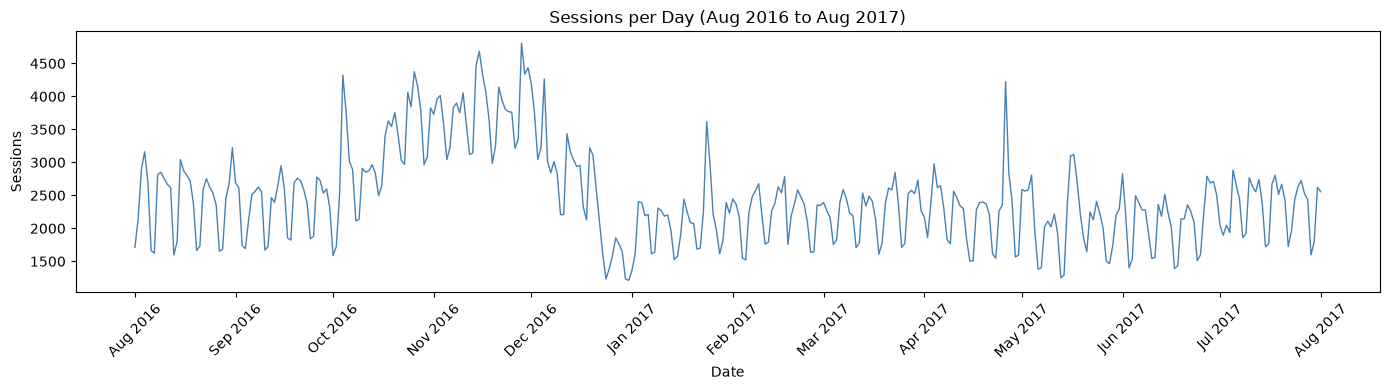

In [13]:
fig, ax = plt.subplots(figsize = (14,4))
ax.plot(df_time_series['session_date'], df_time_series['sessions'], linewidth = 1, color = 'steelblue')
ax.set_title('Sessions per Day (Aug 2016 to Aug 2017)')
ax.set_xlabel('Date')
ax.set_ylabel('Sessions')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/sessions_per_day.png', dpi=150)
plt.show()

**Insights:**
1. Peak traffic Nov/Dec 2016: sessions climbed from ~2,500 in Oct to a peak of ~4,700 in Nov/Dec, likely driven by Black Friday and holiday shopping season.
2. Sharp drop in Jan 2017: sessions fell to ~1,500, a post-holiday slump typical in ecommerce.
3. Weekly pattern throughout: the regular zigzag visible across all months reflects a weekday vs weekend cycle (higher traffic on weekdays).
4. One spike in May 2017: a single day hit ~4,200, worth investigating in EDA (could be a promotion or campaign).
5. Overall trend flat to declining: after the holiday peak, traffic stayed around 2,000 - 2,500 and did not recover to pre-holiday levels.

In [14]:
# check the revenue
revenue_query = """
    SELECT totals.totalTransactionRevenue/1000000 as transactionRevenue
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
    WHERE totals.totalTransactionRevenue IS NOT NULL
"""

df_revenue = client.query(revenue_query).to_dataframe()
print(f"Total transactions: {len(df_revenue)}")
print(df_revenue['transactionRevenue'].describe().round(2))

# right skewed

Total transactions: 11515
count    11515.00
mean       154.59
std        720.48
min          1.20
25%         29.99
50%         55.61
75%        116.62
max      47082.06
Name: transactionRevenue, dtype: float64


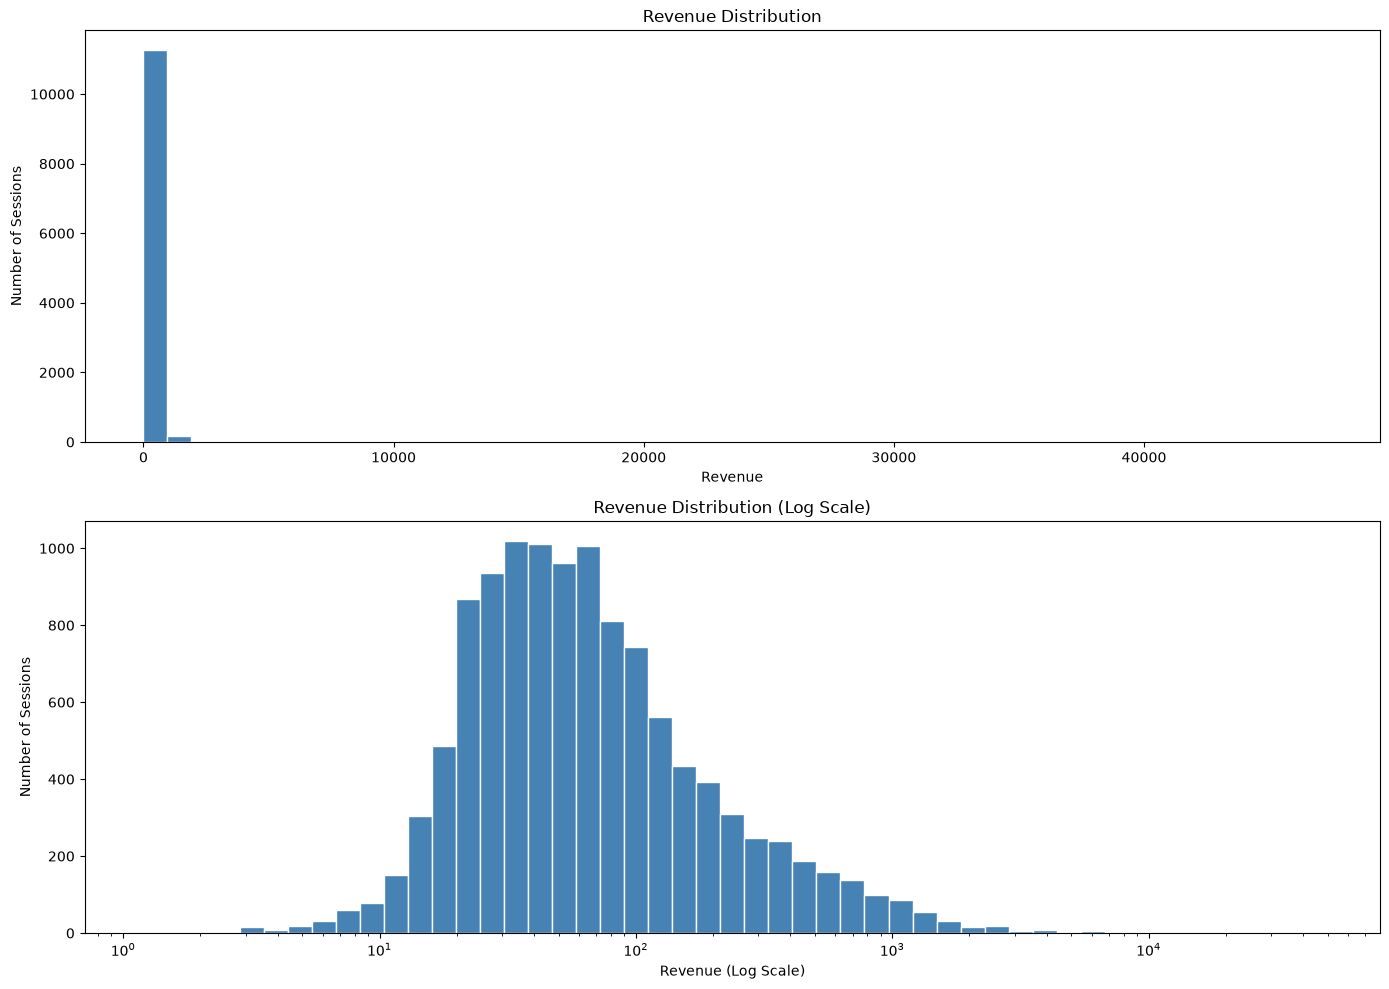

In [15]:
# visualize the revenue
fig, axes = plt.subplots(2, 1, figsize = (14,10))

# left chart (skewed)
axes[0].hist(df_revenue['transactionRevenue'], bins = 50, color = 'steelblue', edgecolor = 'white')
axes[0].set_title('Revenue Distribution')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Number of Sessions')

# right chart
axes[1].hist(df_revenue['transactionRevenue'], bins = np.logspace(np.log10(df_revenue['transactionRevenue'].min()),
                                                                  np.log10(df_revenue['transactionRevenue'].max()),
                                                                  50), 
                                               color = 'steelblue', edgecolor = 'white')
axes[1].set_xscale('log')
axes[1].set_title('Revenue Distribution (Log Scale)')
axes[1].set_xlabel('Revenue (Log Scale)')
axes[1].set_ylabel('Number of Sessions')

plt.tight_layout()
plt.savefig('../images/revenue_distribution.png', dpi=150)

**Insights:**
1. Heavily right-skewed: median revenue is &#36;55.61 but mean is &#36;154.59, pulled up by a small number of very large transactions.
2. Most transactions are small: 75% of purchases are under &#36;117, typical for a merchandise store.
3. Wide value range: transactions range from &#36;1.20 to &#36;47,082, spanning nearly 4 orders of magnitude. The log-scale chart reveals the full spread clearly.
4. Outliers worth noting: a handful of very high-value transactions (above &#36;5,000) could disproportionately affect revenue metrics. Worth filtering or flagging in deeper analysis.

In [16]:
pageviews_query = """
    SELECT totals.pageviews AS pageviews
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
    WHERE totals.pageviews IS NOT NULL
"""
df_pageviews = client.query(pageviews_query).to_dataframe()
print(f"Sessions with pageviews: {len(df_pageviews)}")
print(df_pageviews['pageviews'].describe())
print(f"\nPercentiles (50, 90, 95, 99): {np.percentile(df_pageviews['pageviews'], [50, 90, 95, 99])}")

Sessions with pageviews: 903553
count    903553.0
mean     3.849764
std      7.025274
min           1.0
25%           1.0
50%           1.0
75%           4.0
max         469.0
Name: pageviews, dtype: Float64

Percentiles (50, 90, 95, 99): [ 1.  9. 15. 33.]


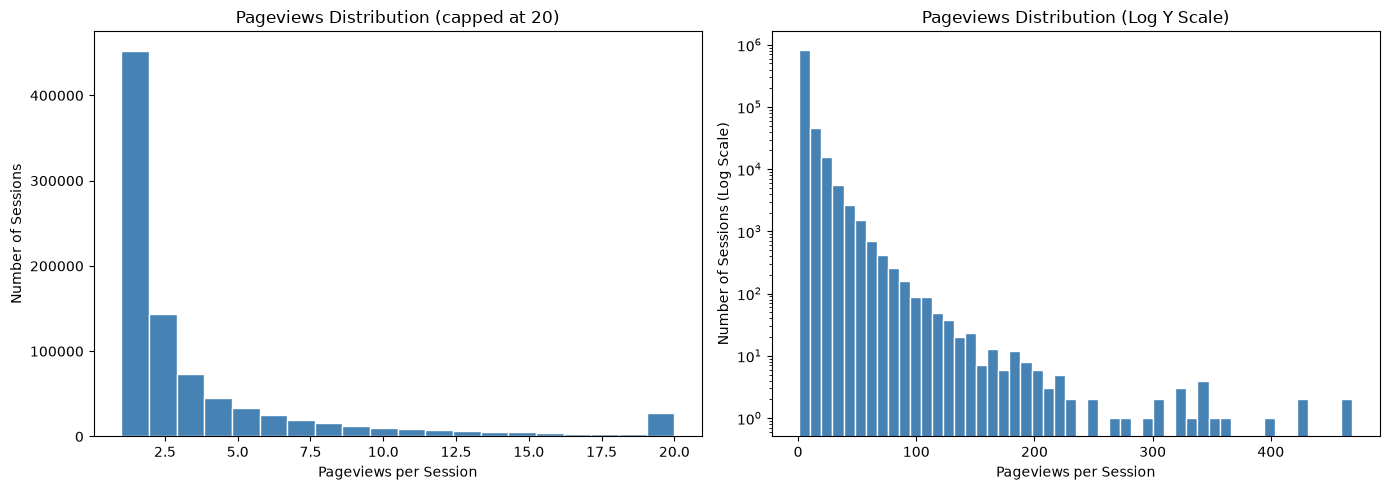

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: capped at 20 to show the main distribution clearly
axes[0].hist(df_pageviews['pageviews'].clip(upper=20), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Pageviews Distribution (capped at 20)')
axes[0].set_xlabel('Pageviews per Session')
axes[0].set_ylabel('Number of Sessions')

# right: full range with log Y to show the long tail
axes[1].hist(df_pageviews['pageviews'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Pageviews Distribution (Log Y Scale)')
axes[1].set_xlabel('Pageviews per Session')
axes[1].set_ylabel('Number of Sessions (Log Scale)')

plt.tight_layout()
plt.savefig('../images/pageviews_distribution.png', dpi=150)
plt.show()

**Insights:**
1. Median is 1: over half of all sessions have just 1 pageview, meaning most visitors view only the landing page.
2. Heavily right-skewed: the left chart (capped at 20) shows most sessions cluster at 1-3 pages. The log Y chart shows the long tail extends to 100+ pages.
3. 90th percentile is 9 pages, 95th is 15, 99th is 33: the majority of engaged sessions stay under 10 pages.
4. High single-page rate suggests a large bounce population, which aligns with the ~50% bounce rate seen in the missing values analysis.